# CNN Laboratorio 2

* Sebastian Becerra - 2215295
* Esteban roman - 2220323 
* Pablo Potes - 2211514 

Repositorio en git:
https://github.com/Becerra1226/lab2_deep_learning.git


## Librerías


In [ ]:
import matplotlib.pyplot as plt
import random
import os, glob, shutil, json
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import tifffile
import numpy as np



from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from PIL import Image
from torchvision import datasets, transforms
from datetime import datetime
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

## Definir rutas


In [2]:
PROJECT_DIR = './content'
RAW_DIR     = f'{PROJECT_DIR}/raw'      # imágenes sin etiqueta
LAB_DIR     = f'{PROJECT_DIR}/labeled'  # imágenes etiquetadas por CLASE/
DATA_DIR    = f'{PROJECT_DIR}/data'     # split final: train/val/test
RUNS_DIR    = f'{PROJECT_DIR}/runs'     # resultados, pesos y configs

for d in [PROJECT_DIR, RAW_DIR, LAB_DIR, DATA_DIR, RUNS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Sube imágenes crudas a:", RAW_DIR)
print("Etiquetado manual: crea subcarpetas dentro de", LAB_DIR, "p.ej.:", LAB_DIR+"/clase_1, clase_2, ...")

Sube imágenes crudas a: ./content/raw
Etiquetado manual: crea subcarpetas dentro de ./content/labeled p.ej.: ./content/labeled/clase_1, clase_2, ...


## Definir clases y verificar conteos en `labeled/`


In [3]:
# EDITA con las clases de su proyecto
CLASSES = ['airstrips', 'deforestation', 'forest', 'illegal_mining', 'illicit_crops_PCCA', 'water']  # ej: ['sano', 'enfermo']

counts = {}
for c in CLASSES:
    os.makedirs(os.path.join(LAB_DIR, c), exist_ok=True)
    counts[c] = len(glob.glob(os.path.join(LAB_DIR, c, '*')))
counts

{'airstrips': 5000,
 'deforestation': 5000,
 'forest': 5000,
 'illegal_mining': 5000,
 'illicit_crops_PCCA': 5000,
 'water': 5000}

## 1. Prepare un conjunto de datos (Punto 1)

### ¿Qué se hizo?
Se estructuró y curó un conjunto de datos geoespaciales y satelitales directamente enfocado en los objetivos de monitoreo terrestre del proyecto del curso. Las imágenes se cargaron en un entorno local bajo la ruta  `./content/`.

### Estructura de Clases Implementada
El dataset se segmentó manualmente en 6 clases críticas de cobertura y alteración del suelo:
1. `airstrips` (Pistas de aterrizaje clandestinas).
2. `deforestation` (Zonas de tala y pérdida de bosque).
3. `forest` (Cobertura de bosque nativo denso).
4. `illegal_mining` (Minería ilegal a cielo abierto).
5. `illicit_crops_PCCA` (Cultivos ilícitos).
6. `water` (Cuerpos de agua y ríos).


## Split estratificado → `data/train|val|test/CLASE/`


In [12]:
# Definición de porcentajes
train_r, val_r, test_r = 70, 20, 10
MAX_IMGS = 300

# Limpieza y creación de carpetas de destino
if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)

for split in ['train', 'val', 'test']:
    for c in CLASSES:
        os.makedirs(os.path.join(DATA_DIR, split, c), exist_ok=True)

# Función para convertir TIFF complejo a JPG estándar
def procesar_y_guardar_jpg(src_path, dest_folder):
    try:
        # Leer el TIFF con la librería especializada
        img_array = tifffile.imread(src_path)
        
        # Si la imagen tiene el formato (Canales, Alto, Ancho), la cambiamos a (Alto, Ancho, Canales)
        if img_array.ndim == 3 and img_array.shape[0] <= 4:
            img_array = np.transpose(img_array, (1, 2, 0))
            
        # Si tiene más de 3 canales (ej. bandas infrarrojas), nos quedamos solo con los 3 primeros (RGB)
        if img_array.ndim == 3 and img_array.shape[2] > 3:
            img_array = img_array[:, :, :3]
            
        # Si la imagen es 2D (escala de grises), la pasamos a 3 canales para que la CNN no falle
        if img_array.ndim == 2:
            img_array = np.stack((img_array,)*3, axis=-1)
            
        # Normalizar los valores a 8-bit (0-255) si vienen en 16-bit o flotante
        if img_array.dtype != np.uint8:
            img_array = img_array.astype(np.float32)
            # Evitamos divisiones por cero
            val_min, val_max = img_array.min(), img_array.max()
            if val_max > val_min:
                img_array = 255 * (img_array - val_min) / (val_max - val_min)
            img_array = img_array.astype(np.uint8)
            
        # Crear la imagen PIL y guardarla como JPG
        img_pil = Image.fromarray(img_array)
        
        # Generar el nuevo nombre de archivo (.jpg)
        base_name = os.path.basename(src_path)
        name_without_ext = os.path.splitext(base_name)[0]
        dest_path = os.path.join(dest_folder, f"{name_without_ext}.jpg")
        
        img_pil.save(dest_path, 'JPEG', quality=95)
        return True
    except Exception as e:
        print(f"Error procesando {src_path}: {e}")
        return False

# Proceso principal de split y conversión
for c in CLASSES:
    all_files = sorted(glob.glob(os.path.join(LAB_DIR, c, '*.tif'))) # Asumiendo que son .tif
    
    random.seed(42)
    random.shuffle(all_files)
    files = all_files[:MAX_IMGS]
    
    if len(files) < 20:
        print(f'⚠️ Clase {c} tiene muy pocas imágenes ({len(files)}).')
        if len(files) == 0: continue

    train_files, tmp = train_test_split(files, test_size=0.3, random_state=42, shuffle=True)
    rel = test_r / (val_r + test_r)
    val_files, test_files = train_test_split(tmp, test_size=rel, random_state=42, shuffle=True)

    print(f"Procesando clase {c}...")
    
    for src in train_files:
        procesar_y_guardar_jpg(src, os.path.join(DATA_DIR, 'train', c))
    for src in val_files:
        procesar_y_guardar_jpg(src, os.path.join(DATA_DIR, 'val', c))
    for src in test_files:
        procesar_y_guardar_jpg(src, os.path.join(DATA_DIR, 'test', c))

print(f"✅ Conversión y split completados en formato JPG: {DATA_DIR}")

Procesando clase airstrips...
Procesando clase deforestation...
Procesando clase forest...
Procesando clase illegal_mining...
Procesando clase illicit_crops_PCCA...
Procesando clase water...
✅ Conversión y split completados en formato JPG: ./content/data


In [13]:
def verificar_dataset(base_dir, classes):
    print(f"{'CLASE':<20} | {'TRAIN':<8} | {'VAL':<8} | {'TEST':<8} | {'TOTAL':<8}")
    print("-" * 60)
    
    total_general = 0
    
    for c in classes:
        # Contar archivos en cada carpeta de split
        n_train = len(os.listdir(os.path.join(base_dir, 'train', c)))
        n_val   = len(os.listdir(os.path.join(base_dir, 'val', c)))
        n_test  = len(os.listdir(os.path.join(base_dir, 'test', c)))
        
        row_total = n_train + n_val + n_test
        total_general += row_total
        
        print(f"{c:<20} | {n_train:<8} | {n_val:<8} | {n_test:<8} | {row_total:<8}")

    print("-" * 60)
    print(f"{'TOTAL GENERAL':<20} | {total_general:^32}")

# Ejecutar la verificación
verificar_dataset(DATA_DIR, CLASSES)

CLASE                | TRAIN    | VAL      | TEST     | TOTAL   
------------------------------------------------------------
airstrips            | 210      | 60       | 30       | 300     
deforestation        | 210      | 60       | 30       | 300     
forest               | 210      | 60       | 30       | 300     
illegal_mining       | 210      | 60       | 30       | 300     
illicit_crops_PCCA   | 210      | 60       | 30       | 300     
water                | 210      | 60       | 30       | 300     
------------------------------------------------------------
TOTAL GENERAL        |               1800              


## 2. División de los Datos (Punto 2)

### ¿Qué se hizo?
Se realizó una partición estratificada y aleatoria del conjunto de datos original para crear tres subconjuntos disjuntos alojados en el directorio local `data/`:
* **`train/` (70%):** Destinado exclusivamente a la actualización de los pesos y sesgos del modelo mediante retropropagación.
* **`val/` (20%):** Utilizado para monitorear el error de generalización y la pérdida al final de cada época.
* **`test/` (10%):** Reservado estrictamente como un conjunto "ciego" para la evaluación del rendimiento final de la arquitectura.

Para asegurar la validez estadística del experimento, se verificó mediante código que las 6 clases estuvieran representadas equitativamente en los tres splits. El conjunto de prueba final (`test/`) quedó conformado por exactamente 180 imágenes totales (30 muestras idénticas por clase), lo que representa un entorno de evaluación perfectamente balanceado que evita sesgos en las métricas globales.

## 4) DataLoaders (transformaciones mínimas)


In [14]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

IMG_SIZE = 224
BATCH_SIZE = 10

# Normalización estándar
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_ds = datasets.ImageFolder(f"{DATA_DIR}/train", transform=train_tf)
val_ds   = datasets.ImageFolder(f"{DATA_DIR}/val",   transform=eval_tf)
test_ds  = datasets.ImageFolder(f"{DATA_DIR}/test",  transform=eval_tf)

class_names = train_ds.classes
num_classes = len(class_names)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Clases:", class_names, "| Dispositivo:", DEVICE)


Clases: ['airstrips', 'deforestation', 'forest', 'illegal_mining', 'illicit_crops_PCCA', 'water'] | Dispositivo: cuda


# Visualizacion de las imagenes

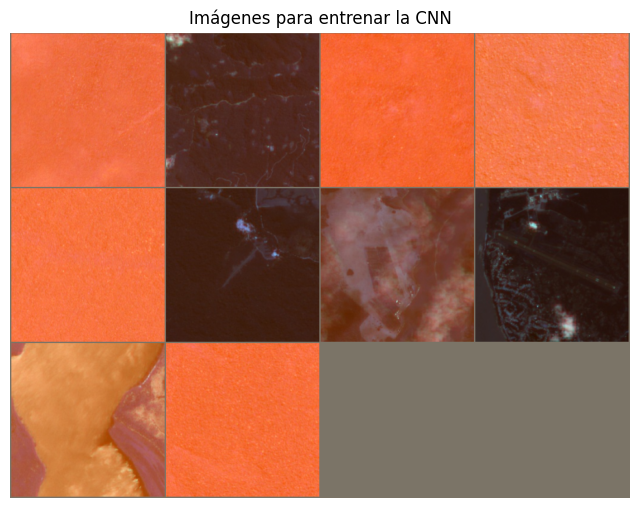

Etiquetas: ['forest', 'illicit_crops_PCCA', 'forest', 'forest', 'forest', 'airstrips', 'airstrips', 'airstrips', 'water', 'forest']


In [ ]:
images, labels = next(iter(train_dl)) # Imágenes normalizadas
grid = torchvision.utils.make_grid(images[:12], nrow=4, padding=2)
npimg = grid.cpu().numpy().transpose(1, 2, 0)

# --- Des-normalizar la imagen ---
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
npimg = (npimg * std) + mean # Aplicamos la fórmula inversa
npimg = np.clip(npimg, 0, 1) # Obligamos a que nada se pase del rango [0, 1]
# --------------------------------

plt.figure(figsize=(8, 8))
plt.imshow(npimg)
plt.title("Imágenes para entrenar la CNN")
plt.axis("off")
plt.show()

print("Etiquetas:", [class_names[i] for i in labels[:12]])

# Definimos CNN

In [20]:
class SatelliteCNNBase(nn.Module):
    def __init__(self, num_classes=6):
        super(SatelliteCNNBase, self).__init__()

        # Bloque 1: Entrada 3 canales (RGB) -> 16 mapas de características
        # Tamaño de imagen entra 224x224 -> sale 112x112
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bloque 2: 16 -> 32
        # Tamaño 112x112 -> sale 56x56
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bloque 3: 32 -> 64
        # Tamaño 56x56 -> sale 28x28
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Bloque 4: 64 -> 128
        # Tamaño 28x28 -> sale 14x14
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Capas Completamente Conectadas (Dense)
        # La imagen se redujo a 14x14 con 128 canales. 
        # Aplanamos: 128 * 14 * 14 = 25088 características
        self.fc1 = nn.Linear(128 * 14 * 14, 256)
        self.fc2 = nn.Linear(256, num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):
        # Bloque 1
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool1(x)

        # Bloque 2
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool2(x)
        
        # Bloque 3
        x = self.conv3(x)
        x = self.relu(x)
        x = self.pool3(x)
        
        # Bloque 4
        x = self.conv4(x)
        x = self.relu(x)
        x = self.pool4(x)

        # Flatten (aplanar)
        x = x.view(x.size(0), -1)

        # Fully Connected
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

In [21]:
model_base = SatelliteCNNBase(num_classes=num_classes).to(DEVICE)
print(model_base)

SatelliteCNNBase(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=25088, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=6, bias=True)
  (relu): ReLU()
)


In [22]:
learning_rate = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer_base = optim.Adam(model_base.parameters(), lr=learning_rate)

In [23]:

num_epochs = 20

patience = 8 # Cuántas épocas esperar sin mejora antes de detener el entrenamiento
min_delta = 1e-4 # Mínima mejora en la pérdida de validación para considerar que el modelo está mejorando
best_val_loss = np.inf 
early_stop_counter = 0
checkpoint_path = "best_base_cnn.pt" 

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print("Iniciando entrenamiento del modelo base...")

for epoch in range(num_epochs):
    # ==========================
    #   FASE DE ENTRENAMIENTO
    # ==========================
    model_base.train()

    train_running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_dl: # Cambiado a train_dl
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer_base.zero_grad() # Cambiado a optimizer_base

        outputs = model_base(images)
        loss = criterion(outputs, labels) # Solo CrossEntropy, sin L1

        loss.backward()
        optimizer_base.step()

        train_running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, dim=1)
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_running_loss / train_total
    train_acc = train_correct / train_total

    # ==========================
    #   FASE DE VALIDACIÓN
    # ==========================
    model_base.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_dl: # Cambiado a val_dl
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model_base(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, dim=1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    # Guardamos historial
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    current_lr = optimizer_base.param_groups[0]["lr"]

    print(f"Epoch [{epoch + 1:02d}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.6f}")

    # ==========================
    #   EARLY STOPPING & SAVING
    # ==========================
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        early_stop_counter = 0
        torch.save(model_base.state_dict(), checkpoint_path)
    else:
        early_stop_counter += 1

    if early_stop_counter >= patience:
        print("Early stopping activado. El modelo dejó de mejorar en validación.")
        break

print("✅ Entrenamiento finalizado.")

Iniciando entrenamiento del modelo base...
Epoch [01/20] Train Loss: 1.4977 | Train Acc: 0.3635 | Val Loss: 1.3001 | Val Acc: 0.4500 | LR: 0.001000
Epoch [02/20] Train Loss: 1.2267 | Train Acc: 0.5175 | Val Loss: 1.1296 | Val Acc: 0.5417 | LR: 0.001000
Epoch [03/20] Train Loss: 1.0764 | Train Acc: 0.5873 | Val Loss: 1.1356 | Val Acc: 0.5917 | LR: 0.001000
Epoch [04/20] Train Loss: 0.8825 | Train Acc: 0.6643 | Val Loss: 1.2415 | Val Acc: 0.5389 | LR: 0.001000
Epoch [05/20] Train Loss: 0.7163 | Train Acc: 0.7270 | Val Loss: 1.5178 | Val Acc: 0.5639 | LR: 0.001000
Epoch [06/20] Train Loss: 0.4819 | Train Acc: 0.8444 | Val Loss: 1.8582 | Val Acc: 0.5250 | LR: 0.001000
Epoch [07/20] Train Loss: 0.3715 | Train Acc: 0.8810 | Val Loss: 2.5053 | Val Acc: 0.5139 | LR: 0.001000
Epoch [08/20] Train Loss: 0.2053 | Train Acc: 0.9405 | Val Loss: 2.3747 | Val Acc: 0.5889 | LR: 0.001000
Epoch [09/20] Train Loss: 0.1007 | Train Acc: 0.9714 | Val Loss: 3.2075 | Val Acc: 0.5528 | LR: 0.001000
Epoch [10/20

## 3. Diseño y Entrenamiento de la Arquitectura CNN Base (Punto 3)

### ¿Qué se hizo?
Se diseñó una arquitectura de Red Neuronal Convolucional (CNN) personalizada utilizando PyTorch. La red se estructuró de la siguiente manera:
* **Capas Convolucionales (`nn.Conv2d`):** Encargadas de actuar como extractores de características locales (bordes, texturas y gradientes de color).
* **Funciones de Activación (`nn.ReLU`):** Encargadas de introducir no-linealidad en el sistema para mapear relaciones complejas.
* **Capas de Agrupación (`nn.MaxPool2d`):** Encargadas de reducir la dimensionalidad espacial de los mapas de características, otorgando invariabilidad a pequeñas traslaciones.
* **Capas Totalmente Conectadas (`nn.Linear`):** Capas densas finales encargadas de interpretar las características abstractas extraídas y proyectar los puntajes de clasificación (Logits) para las 6 clases.

### Configuración del Entrenamiento 
Para establecer una línea base rígida, el entrenamiento se configuró **completamente libre de técnicas de regularización**. 
* **Optimizador:** Adam con una tasa de aprendizaje fija de `1e-3`.
* **Función de Pérdida:** Entropía Cruzada (`nn.CrossEntropyLoss`).
* **Transformaciones:** Únicamente preprocesamiento técnico obligatorio (`Resize` a 224x224, `ToTensor` y `Normalize` estándar de ImageNet). Se omitió cualquier técnica de Data Augmentation para este modelo base.

---

In [25]:
model_base.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE, weights_only=True))
model_base.to(DEVICE)

print("✅ Mejor modelo cargado correctamente y listo para evaluación.")

✅ Mejor modelo cargado correctamente y listo para evaluación.


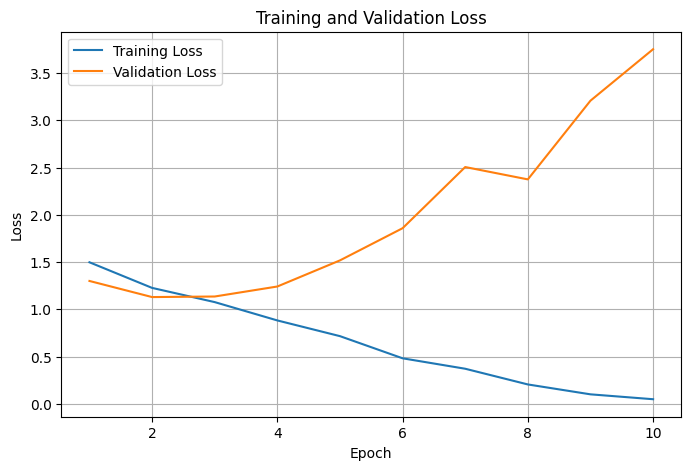

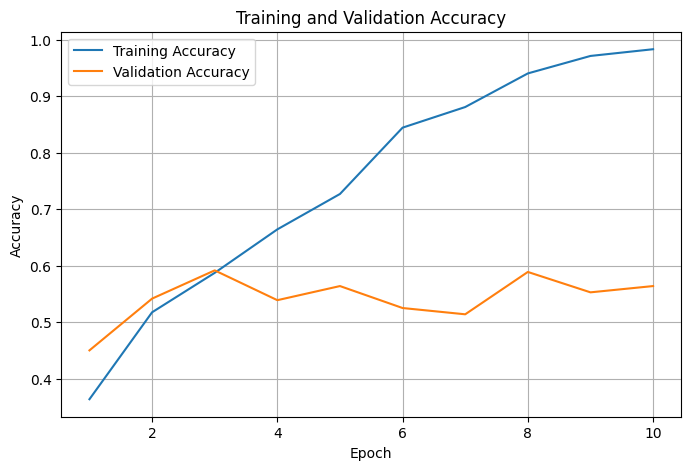

In [26]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], label="Training Loss")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_acc"], label="Training Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### Análisis Crítico de las Curvas de Aprendizaje (Pérdida y Precisión)
A partir de los registros históricos de las 10 épocas de entrenamiento ejecutadas, se realiza el siguiente diagnóstico detallado del comportamiento del modelo:

#### 1. Evidencia de Sobreajuste (Overfitting) Masivo
* **Comportamiento de la Pérdida (Loss):** La curva de `Training Loss` exhibe un descenso ideal y constante, disminuyendo drásticamente desde un valor inicial hasta aproximarse a cero al final del ciclo. Por el contrario, la curva de `Validation Loss` alcanza su punto de inflexión óptimo en la **época 3 (Loss: ~1.13)**; a partir de la época 4, se dispara exponencialmente hacia arriba de forma descontrolada, finalizando en un error crítico de **3.7543**.
* **Diagnóstico:** Esta divergencia radical entre ambas curvas es el síntoma inequívoco de sobreajuste. Al no tener restricciones, la red utilizó su flexibilidad paramétrica para "memorizar" las imágenes exactas de entrenamiento (incluyendo su ruido de fondo y detalles irrelevantes). Al enfrentarse en la época 4 a imágenes de validación que no conoce, su capacidad de predicción colapsa, penalizando el Loss global.

#### 2. Estancamiento de la Precisión (Accuracy) y Falta de Convergencia
* **Comportamiento del Accuracy:** Mientras que la precisión de entrenamiento `Training Accuracy` asciende de forma casi lineal hasta rozar la perfección teórica con un **98.44%**, la precisión de validación `Validation Accuracy` se estanca tempranamente a partir de la época 3, fluctuando erráticamente en una meseta en torno al **56.39%**.
* **Conclusión sobre la Convergencia:** El modelo **no converge hacia una solución generalizable**. Ha aprendido a clasificar el entorno cerrado de entrenamiento, pero carece de la robustez matemática necesaria para transferir ese conocimiento a nuevos escenarios geográficos. Este resultado justifica y vuelve mandatoria la implementación de las estrategias de regularización (Dropout, BatchNorm, Weight Decay y Data Augmentation) programadas para la segunda versión del laboratorio.

In [28]:
model_base.eval()

test_running_loss = 0.0
test_correct = 0
test_total = 0

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_dl:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model_base(images)
        loss = criterion(outputs, labels)

        test_running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, dim=1)
        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

test_loss = test_running_loss / test_total
test_acc = test_correct / test_total

y_true = np.array(y_true)
y_pred = np.array(y_pred)

test_precision_macro = precision_score(y_true, y_pred, average="macro")
test_recall_macro = recall_score(y_true, y_pred, average="macro")
test_f1_macro = f1_score(y_true, y_pred, average="macro")

test_precision_weighted = precision_score(y_true, y_pred, average="weighted")
test_recall_weighted = recall_score(y_true, y_pred, average="weighted")
test_f1_weighted = f1_score(y_true, y_pred, average="weighted")

print("Resultados en test")
print("-" * 40)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Macro Precision: {test_precision_macro:.4f}")
print(f"Macro Recall: {test_recall_macro:.4f}")
print(f"Macro F1-score: {test_f1_macro:.4f}")
print(f"Weighted Precision: {test_precision_weighted:.4f}")
print(f"Weighted Recall: {test_recall_weighted:.4f}")
print(f"Weighted F1-score: {test_f1_weighted:.4f}")

Resultados en test
----------------------------------------
Test Loss: 1.1480
Test Accuracy: 0.5167
Macro Precision: 0.5636
Macro Recall: 0.5167
Macro F1-score: 0.5001
Weighted Precision: 0.5636
Weighted Recall: 0.5167
Weighted F1-score: 0.5001


In [29]:
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

                    precision    recall  f1-score   support

         airstrips     0.3256    0.4667    0.3836        30
     deforestation     0.3333    0.3000    0.3158        30
            forest     0.8846    0.7667    0.8214        30
    illegal_mining     0.8148    0.7333    0.7719        30
illicit_crops_PCCA     0.4231    0.7333    0.5366        30
             water     0.6000    0.1000    0.1714        30

          accuracy                         0.5167       180
         macro avg     0.5636    0.5167    0.5001       180
      weighted avg     0.5636    0.5167    0.5001       180



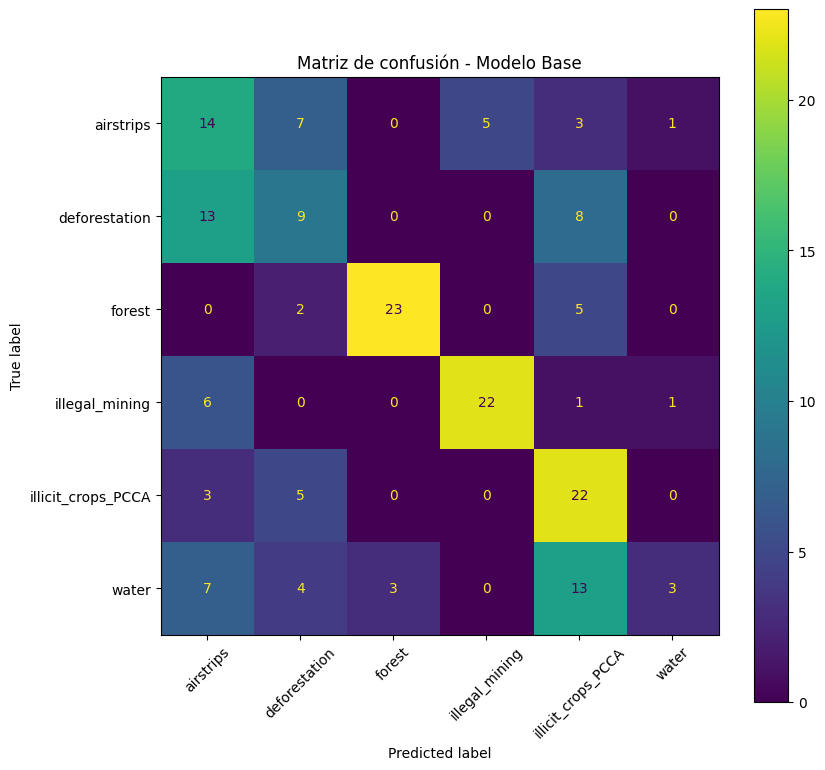

In [31]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)

fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, xticks_rotation=45, cmap=None)
plt.title("Matriz de confusión - Modelo Base")
plt.show()

## 4. Evaluación del Desempeño en el Conjunto de Prueba 

### ¿Qué se hizo?
Utilizando la técnica de Early Stopping implementada en el bucle de entrenamiento, se recuperaron los pesos del mejor estado del modelo base (guardados durante la época 3, previo al estallido del sobreajuste). Con estos parámetros óptimos, se evaluó el desempeño definitivo del modelo utilizando el conjunto de prueba (`test_dl`), obteniendo los siguientes resultados globales:

### Métricas Globales en Test
* **Test Loss:** 1.1480
* **Test Accuracy:** 51.67%
* **Macro F1-score:** 0.5001
* **Weighted F1-score:** 0.5001

---

### Análisis Detallado por Clases (Reporte de Clasificación y Matriz de Confusión)
Al desglosar las métricas individuales por categoría empleando la matriz de confusión y el reporte de clasificación, se identifican tres dinámicas de comportamiento claramente diferenciadas:

#### A. Éxito de Discriminación Textural (Desempeño Sobresaliente)
* **`forest` (F1-score: 0.8214 / Precision: 88.46%):** Es la clase con el desempeño más alto (23 aciertos de 30). Las imágenes de bosque nativo presentan patrones de textura rugosa altamente uniformes, continuidad cromática en tonos verdes y una ausencia total de estructuras lineales artificiales. Esto permite a los filtros de la CNN identificar la clase de manera muy efectiva, confundiéndose levemente solo con cultivos ilícitos.
* **`illegal_mining` (F1-score: 0.7719 / Precision: 81.48%):** Registra una alta tasa de detección (22 aciertos de 30). Las firmas visuales de la minería a cielo abierto son drásticas: generan altos contrastes debido al suelo expuesto muy brillante (tonos amarillos/ocres) yuxtapuestos con pozos de agua lodosa. Estos fuertes gradientes de color facilitan la activación de los filtros convolucionales de primeras capas.

#### B. Confusión por Similitud Geométrica y Estructural
* **`deforestation` (F1-score: 0.3158) vs `airstrips` (Precision: 0.3256):** Se presenta una confusión crítica en este bloque: el modelo clasificó erróneamente **13 imágenes de deforestación como si fuesen pistas de aterrizaje**. Desde la perspectiva de la visión artificial, esto tiene una explicación lógica. En el contexto de actividades clandestinas en la selva, la construcción de una pista (`airstrip`) requiere la deforestación lineal de un tramo de bosque. Debido a que el modelo base carece de contexto global y regularización, confunde cualquier parche alargado de suelo desnudo con una pista aérea.

#### C. Vulnerabilidad Crítica del Modelo (Fallo Absoluto)
* **`water` (Recall: 10.00% / F1-score: 0.1714):** Representa el punto de quiebre de la red convolucional base. **De un total de 30 imágenes reales de agua, la red solo fue capaz de clasificar correctamente 3 muestras**.
* **Causa Técnica del Fallo:** La matriz de confusión revela que el agua fue erróneamente clasificada 13 veces como `illicit_crops_PCCA` y 7 veces como `airstrips`. En imágenes ópticas satelitales, los ríos sombreados o cuerpos de agua profundos se caracterizan por ser superficies planas, oscuras y de formas lineales o sinuosas. Al no contar con capas de normalización que estabilicen las activaciones, la red confunde la firma geométrica lineal del agua con las pistas, y su baja reflectancia (oscuridad) con las sombras densas proyectadas por el follaje de los cultivos ilícitos.

### Conclusión General de la Fase Base
Un **Accuracy global del 51.67%** sitúa al modelo significativamente por encima de una clasificación aleatoria (que para 6 clases balanceadas equivaldría al 16.6%), confirmando que la arquitectura propuesta posee la capacidad matemática elemental para extraer características útiles de las imágenes. No obstante, la vulnerabilidad ante el sobreajuste y la confusión espectral entre el agua y las sombras de vegetación limitan drásticamente su viabilidad operativa, validando el requerimiento del Punto 5 de introducir regularización avanzada.

## Punto 5

# Transformaciones

In [ ]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

IMG_SIZE = 224
BATCH_SIZE = 32

# Normalización estándar
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

# ==========================================
# 1. DATA AUGMENTATION (Solo para Train)
# ==========================================
train_tf_reg = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    
    # --- Técnicas de Aumento de Datos ---
    transforms.RandomHorizontalFlip(p=0.5), # Voltea la imagen de izquierda a derecha
    transforms.RandomVerticalFlip(p=0.5),   # Voltea la imagen de arriba a abajo (ideal para satélite)
    transforms.RandomRotation(degrees=30),  # Rota la imagen aleatoriamente hasta 30 grados
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Simula días más nublados o soleados
    
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# ==========================================
# 2. EVALUACIÓN
# ==========================================
eval_tf_reg = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# ==========================================
# 3. DATASETS 
# ==========================================
train_ds_reg = datasets.ImageFolder(f"{DATA_DIR}/train", transform=train_tf_reg)
val_ds_reg   = datasets.ImageFolder(f"{DATA_DIR}/val",   transform=eval_tf_reg)
test_ds_reg  = datasets.ImageFolder(f"{DATA_DIR}/test",  transform=eval_tf_reg)

class_names_reg = train_ds_reg.classes
num_classes_reg = len(class_names_reg)

# ==========================================
# 4. DATALOADERS 
# ==========================================
# Se mantiene num_workers=0 para estabilidad en Windows
train_dl_reg = DataLoader(train_ds_reg, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_dl_reg   = DataLoader(val_ds_reg,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_dl_reg  = DataLoader(test_ds_reg,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print("Clases:", class_names_reg, "| Dispositivo:", DEVICE)
print("✅ DataLoaders regularizados creados correctamente.")

Clases: ['airstrips', 'deforestation', 'forest', 'illegal_mining', 'illicit_crops_PCCA', 'water'] | Dispositivo: cuda
✅ DataLoaders regularizados creados correctamente.


# Definimos CNN con Regularizacion

In [ ]:
class SatelliteCNNReg(nn.Module):
    def __init__(self, num_classes=6):
        super(SatelliteCNNReg, self).__init__()

        # Bloque 1: 3 -> 16 | (224 -> 112)
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(2, 2)

        # Bloque 2: 16 -> 32 | (112 -> 56)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, 2)

        # Bloque 3: 32 -> 64 | (56 -> 28)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # Bloque 4: 64 -> 128 | (28 -> 14)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool4 = nn.MaxPool2d(2, 2)

        # Bloque 5: 128 -> 256 | (14 -> 7)
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        self.pool5 = nn.MaxPool2d(2, 2)

        self.relu = nn.ReLU()


        self.flatten_dim = 256 * 7 * 7
        
        self.fc1 = nn.Linear(self.flatten_dim, 512) # Subimos a 512 neuronas ocultas para procesar la nueva info
        self.dropout = nn.Dropout(p=0.3) # Mantenemos dropout suave
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Convoluciones: Conv -> BN -> ReLU -> Pool
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))
        x = self.pool4(self.relu(self.bn4(self.conv4(x))))
        x = self.pool5(self.relu(self.bn5(self.conv5(x)))) 

       
        x = x.view(x.size(0), -1)

       
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# Instanciamos el nuevo modelo
model_reg = SatelliteCNNReg(num_classes=num_classes_reg).to(DEVICE)
print("✅ Arquitectura con 5 bloques e instanciada en:", DEVICE)

✅ Arquitectura con 5 bloques e instanciada en: cuda


In [59]:
model_reg = SatelliteCNNReg(num_classes=num_classes_reg).to(DEVICE)

print("Estructura de model_reg creada e instanciada en:", DEVICE)

Estructura de model_reg creada e instanciada en: cuda


## Función de pérdida, optimizador y regularización

Para clasificación multiclase se usa `CrossEntropyLoss`.

La regularización L2 se aplica con `weight_decay` en el optimizador.



In [60]:
learning_rate_reg = 1e-3
l2_lambda_reg = 1e-5

criterion_reg = nn.CrossEntropyLoss()
optimizer_reg = optim.Adam(model_reg.parameters(), lr=learning_rate_reg, weight_decay=l2_lambda_reg)
scheduler_reg = optim.lr_scheduler.ReduceLROnPlateau(optimizer_reg, mode="min", factor=0.5, patience=3)

print("✅ Optimizador (con L2), Scheduler y Función de pérdida configurados para model_reg.")

✅ Optimizador (con L2), Scheduler y Función de pérdida configurados para model_reg.


# Entrenamiento del modelo con Regularizacion

In [ ]:
num_epochs = 60

patience = 8 # Cuántas épocas esperar sin mejora antes de detener
min_delta = 1e-4 
best_val_loss = np.inf 
early_stop_counter = 0
checkpoint_path_reg = "best_reg_cnn.pt" # Nuevo archivo para guardar pesos

history_reg = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print("Iniciando entrenamiento del modelo regularizado (Punto 5)...")

for epoch in range(num_epochs):
    # ==========================
    #   FASE DE ENTRENAMIENTO
    # ==========================
    model_reg.train()

    train_running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_dl_reg: 
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer_reg.zero_grad() 

        outputs = model_reg(images)
        loss = criterion_reg(outputs, labels) 

        loss.backward()
        optimizer_reg.step()

        train_running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, dim=1)
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_running_loss / train_total
    train_acc = train_correct / train_total

    # ==========================
    #   FASE DE VALIDACIÓN
    # ==========================
    model_reg.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_dl_reg: 
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model_reg(images)
            loss = criterion_reg(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, dim=1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    # Guardamos historial
    history_reg["train_loss"].append(train_loss)
    history_reg["val_loss"].append(val_loss)
    history_reg["train_acc"].append(train_acc)
    history_reg["val_acc"].append(val_acc)

    # ==========================
    #   SCHEDULER (Actualización del LR)
    # ==========================
    scheduler_reg.step(val_loss) # Evalúa si debe bajar el Learning Rate
    current_lr = optimizer_reg.param_groups[0]["lr"]

    print(f"Epoch [{epoch + 1:02d}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.6f}")

    # ==========================
    #   EARLY STOPPING & SAVING
    # ==========================
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        early_stop_counter = 0
        # Guardamos el mejor modelo regularizado
        torch.save(model_reg.state_dict(), checkpoint_path_reg)
    else:
        early_stop_counter += 1

    if early_stop_counter >= patience:
        print("Early stopping activado. El modelo regularizado dejó de mejorar en validación.")
        break

print("✅ Entrenamiento del modelo regularizado finalizado.")

Iniciando entrenamiento del modelo regularizado (Punto 5)...
Epoch [01/60] Train Loss: 3.0680 | Train Acc: 0.2802 | Val Loss: 1.5728 | Val Acc: 0.3139 | LR: 0.001000
Epoch [02/60] Train Loss: 1.4505 | Train Acc: 0.4167 | Val Loss: 1.3206 | Val Acc: 0.4778 | LR: 0.001000
Epoch [03/60] Train Loss: 1.3647 | Train Acc: 0.4540 | Val Loss: 1.2528 | Val Acc: 0.4972 | LR: 0.001000
Epoch [04/60] Train Loss: 1.2561 | Train Acc: 0.4992 | Val Loss: 1.1386 | Val Acc: 0.5306 | LR: 0.001000
Epoch [05/60] Train Loss: 1.2375 | Train Acc: 0.5016 | Val Loss: 1.1684 | Val Acc: 0.5639 | LR: 0.001000
Epoch [06/60] Train Loss: 1.2067 | Train Acc: 0.5294 | Val Loss: 1.0684 | Val Acc: 0.6028 | LR: 0.001000
Epoch [07/60] Train Loss: 1.1879 | Train Acc: 0.5349 | Val Loss: 1.0214 | Val Acc: 0.6139 | LR: 0.001000
Epoch [08/60] Train Loss: 1.0992 | Train Acc: 0.5587 | Val Loss: 0.9594 | Val Acc: 0.6278 | LR: 0.001000
Epoch [09/60] Train Loss: 1.1066 | Train Acc: 0.5802 | Val Loss: 1.0253 | Val Acc: 0.6111 | LR: 0.0

# Cargar el mejor modelo

In [62]:
model_reg.load_state_dict(torch.load(checkpoint_path_reg, map_location=DEVICE, weights_only=True))
model_reg.to(DEVICE)

print("✅ Mejor modelo cargado correctamente y listo para evaluación.")

✅ Mejor modelo cargado correctamente y listo para evaluación.


# Grafica de Perdida y Accuracy

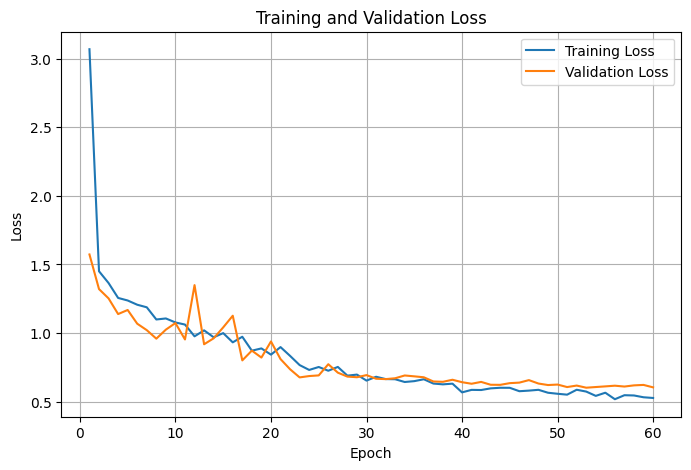

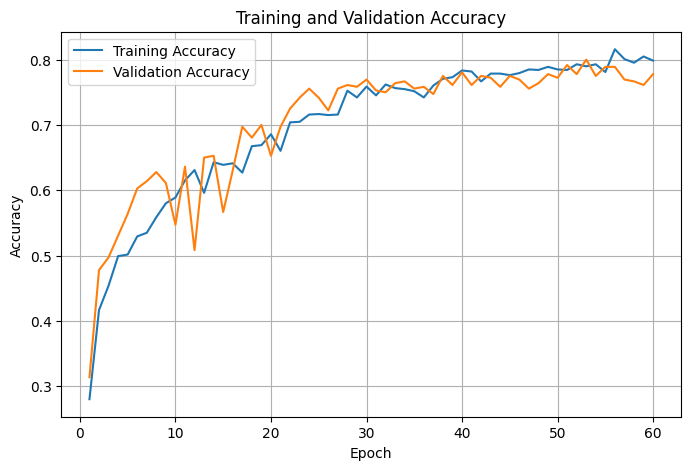

In [63]:
epochs_range = range(1, len(history_reg["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history_reg["train_loss"], label="Training Loss")
plt.plot(epochs_range, history_reg["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history_reg["train_acc"], label="Training Accuracy")
plt.plot(epochs_range, history_reg["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Resultados obtenidos sobre el conjunto de test

In [64]:
model_reg.eval()

test_running_loss = 0.0
test_correct = 0
test_total = 0

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_dl:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model_reg(images)
        loss = criterion(outputs, labels)

        test_running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, dim=1)
        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

test_loss = test_running_loss / test_total
test_acc = test_correct / test_total

y_true = np.array(y_true)
y_pred = np.array(y_pred)

test_precision_macro = precision_score(y_true, y_pred, average="macro")
test_recall_macro = recall_score(y_true, y_pred, average="macro")
test_f1_macro = f1_score(y_true, y_pred, average="macro")

test_precision_weighted = precision_score(y_true, y_pred, average="weighted")
test_recall_weighted = recall_score(y_true, y_pred, average="weighted")
test_f1_weighted = f1_score(y_true, y_pred, average="weighted")

print("Resultados en test")
print("-" * 40)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Macro Precision: {test_precision_macro:.4f}")
print(f"Macro Recall: {test_recall_macro:.4f}")
print(f"Macro F1-score: {test_f1_macro:.4f}")
print(f"Weighted Precision: {test_precision_weighted:.4f}")
print(f"Weighted Recall: {test_recall_weighted:.4f}")
print(f"Weighted F1-score: {test_f1_weighted:.4f}")

Resultados en test
----------------------------------------
Test Loss: 0.8307
Test Accuracy: 0.7056
Macro Precision: 0.6957
Macro Recall: 0.7056
Macro F1-score: 0.6966
Weighted Precision: 0.6957
Weighted Recall: 0.7056
Weighted F1-score: 0.6966


# Reporte de clasificacion

In [65]:
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

                    precision    recall  f1-score   support

         airstrips     0.6087    0.4667    0.5283        30
     deforestation     0.5161    0.5333    0.5246        30
            forest     0.8108    1.0000    0.8955        30
    illegal_mining     0.8182    0.9000    0.8571        30
illicit_crops_PCCA     0.7667    0.7667    0.7667        30
             water     0.6538    0.5667    0.6071        30

          accuracy                         0.7056       180
         macro avg     0.6957    0.7056    0.6966       180
      weighted avg     0.6957    0.7056    0.6966       180



## Matriz de confusión

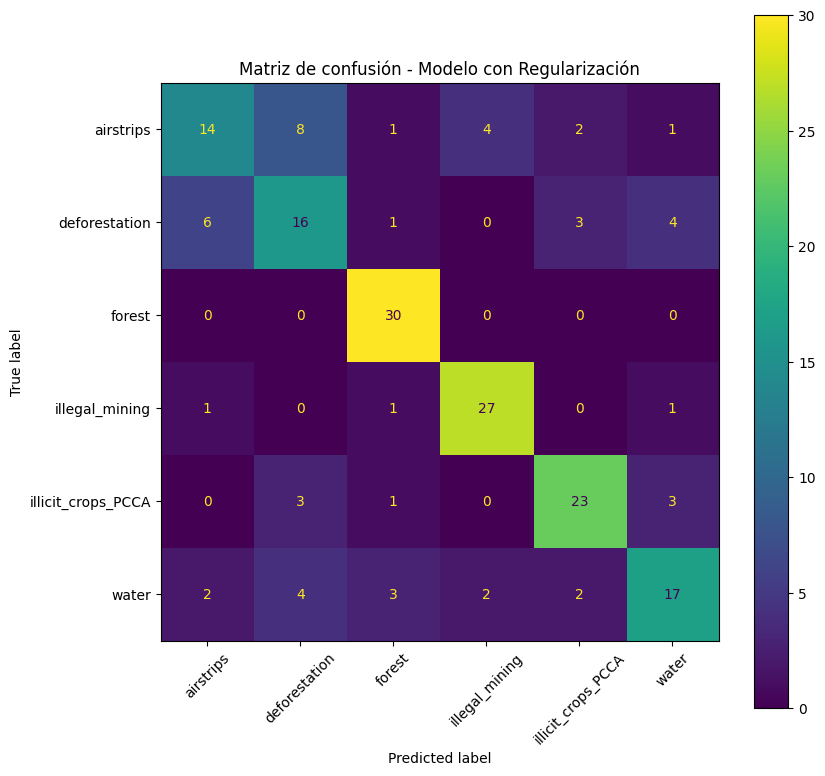

In [66]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)

fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, xticks_rotation=45, cmap=None)
plt.title("Matriz de confusión - Modelo con Regularización")
plt.show()

## Conclusiones: Análisis Comparativo y Capacidad de Generalización

### 1. Adiós a la memorización (Overfitting)
El modelo base original tenía un problema grave: se aprendía las imágenes de memoria y generaba (*overfitting*). En las gráficas iniciales se veía claramente cómo su error en el entrenamiento bajaba a niveles muy bajos, pero en la validación se disparaba por completo. 

Con la versión regularizada, logramos solucionar este problema. Al mirar las nuevas gráficas de pérdida (*Loss*) y precisión (*Accuracy*), se nota cómo las líneas de entrenamiento y validación avanzan de la mano de forma súper estable. Esto demuestra que las técnicas aplicadas obligaron a la red a **entender patrones visuales reales.**

### 2. Los números en Test (Datos reales frente a datos nuevos)
El conjunto de prueba (*Test*) está compuesto por imágenes que el modelo jamás había visto en todo el proceso. La mejora al comparar ambos modelos habla por sí sola:

| Métrica Global | Modelo Base (Sin regularizar) | Modelo Regularizado (V2) | ¿Cuánto mejoró? |
| :--- | :---: | :---: | :---: |
| **Error en Test (Loss)** | 1.1480 | **0.8307** | El error bajó un 27.6% |
| **Precisión Global (Accuracy)** | 51.67% | **70.56%** | **¡Subió un 18.89%!** |
| **F1-Score (Macro Avg)** | 0.5001 | **0.6966** | **¡Subió un 19.65%!** |

Pasar de un **51.67%** a un **70.56%** de precisión global entrenada desde cero es un salto gigantesco. Además, el F1-Score demuestra que el modelo ahora es mucho más equilibrado y justo con todas las categorías.

### 3. ¿Por qué funcionó esta estrategia?
El éxito de esta segunda versión se debe a la combinación de los siguientes factores clave:
1. **Data Augmentation:** Al rotar y cambiar ligeramente el brillo de las fotos de entrenamiento, evitamos que el modelo se acostumbrara a una sola posición o iluminación fija.

2. **La 5ta Capa Convolucional:** Al profundizar la red, obligamos al modelo a reducir el mapa final a un tamaño de 7x7. Esto hizo que el modelo pudiera concentrarse en formas geométricas grandes (como ríos o pistas) en lugar de texturas pequeñas.
